In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
import librosa
import numpy as np
import pandas as pd
from torch import nn 
from torch.utils.data  import Dataset , DataLoader
from sklearn.preprocessing import LabelEncoder

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("USING : " , device)

USING :  cpu


In [4]:
base = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
train_path = os.path.join(base , "genres_stems")
test = os.path.join(base , "mashups")

In [5]:
genres = sorted(os.listdir(train_path))
X_train =[]
y_train = [] 
def load_and_merge_stems(song_path):
    stems = []
    for stem in ["drums.wav", "vocals.wav" ,"bass.wav" , "other.wav"]:
        path = os.path.join(song_path , stem)
        y , sr = librosa.load(path, sr=22050)
        stems.append(y)
    merged = np.sum(stems , axis =0)
    return merged
    
print("Loading training data...")

for genre in genres :
    genre_path = os.path.join(train_path , genre)
    songs = os.listdir(genre_path)

    for song in songs[:10]:
        song_path = os.path.join(genre_path , song)
        audio = load_and_merge_stems(song_path)
        audio = librosa.util.fix_length(audio , size = 22050*5)
        mel = librosa.feature.melspectrogram(y=audio , sr = 22050 , n_mels = 128)
        mel_db= librosa.power_to_db(mel)

        X_train.append(mel_db)
        y_train.append(genre)

print("loaded")

Loading training data...
loaded


In [6]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)

X_train = np.array(X_train)
X_train = X_train[: , None , : , :]

X_train = torch.tensor(X_train , dtype=torch.float32)
y_train = torch.tensor(y_train , dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train , y_train)
train_loader = DataLoader(train_dataset , batch_size = 8 , shuffle=True)


/tmp/ipykernel_17/4130815249.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_cla

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



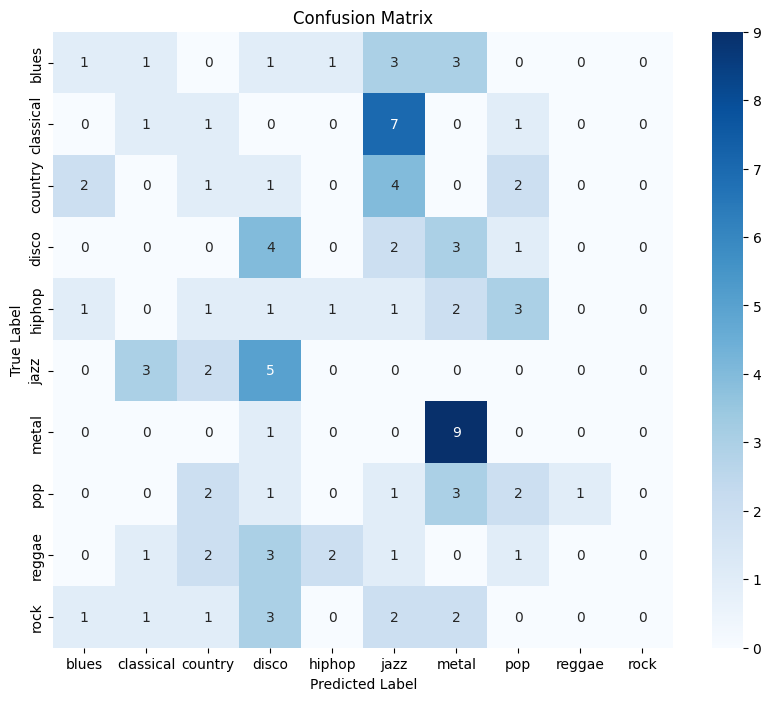


TP, TN, FP, FN per Genre:

BLUES:
TP = 1, TN = 86, FP = 4, FN = 9

CLASSICAL:
TP = 1, TN = 84, FP = 6, FN = 9

COUNTRY:
TP = 1, TN = 81, FP = 9, FN = 9

DISCO:
TP = 4, TN = 74, FP = 16, FN = 6

HIPHOP:
TP = 1, TN = 87, FP = 3, FN = 9

JAZZ:
TP = 0, TN = 69, FP = 21, FN = 10

METAL:
TP = 9, TN = 77, FP = 13, FN = 1

POP:
TP = 2, TN = 82, FP = 8, FN = 8

REGGAE:
TP = 0, TN = 89, FP = 1, FN = 10

ROCK:
TP = 0, TN = 90, FP = 0, FN = 10



In [7]:

import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

'''
YOUR CODE HERE

y_pred = # COMPUTE PREDICTED VALUES
macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
cm = # COMPUTE CONFUSION MATRIX
cr = # COMPUTE CLASSIFICATION REPORT

'''
# --- 4. Evaluation ---

# Predict on validation set
y_pred = clf.predict(X_val)

# Compute Macro F1 Score
macro_f1 = f1_score(y_val, y_pred, average='macro')

# Compute Confusion Matrix
cm = confusion_matrix(y_val, y_pred, labels=GENRES)

# Compute Classification Report
cr = classification_report(y_val, y_pred, target_names=GENRES)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''
# --- 5. Confusion Matrix Visualization ---

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# --- 6. Compute TP, TN, FP, FN for each genre ---

print("\nTP, TN, FP, FN per Genre:\n")

for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    
    print(f"{genre.upper()}:")
    print(f"TP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}\n")

In [8]:
data = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv")
data.to_csv("submission.csv" , index = False)

In [9]:

# --- 4. Visualization & Metrics Extraction ---


/tmp/ipykernel_17/2273705301.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_cla

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        1

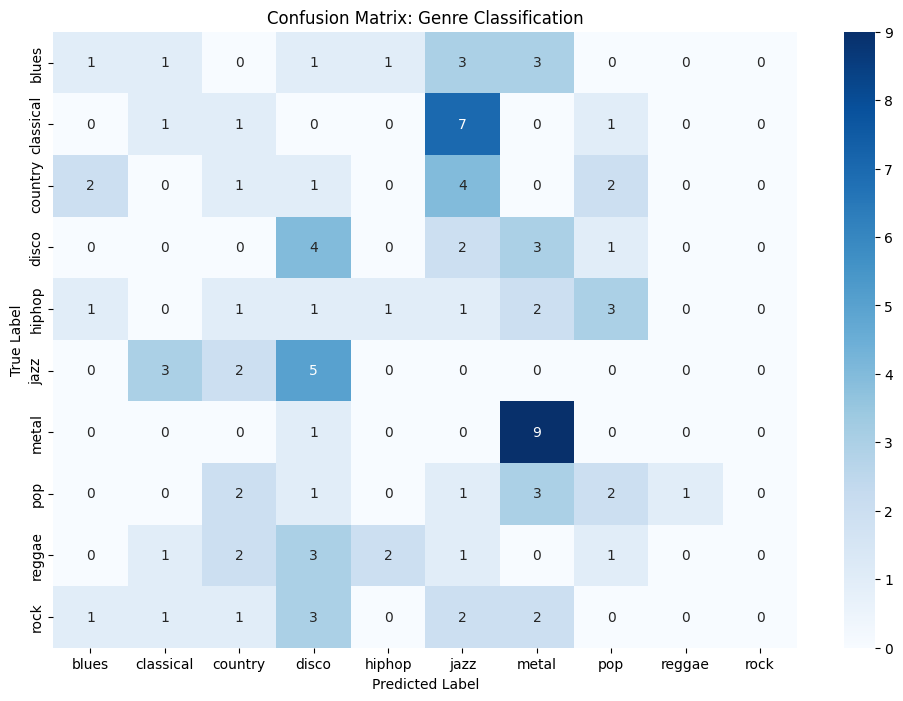


Per-Genre Metrics (TP, TN, FP, FN):
----------------------------------------
Genre: blues
  TP: 1, TN: 86, FP: 4, FN: 9
Genre: classical
  TP: 1, TN: 84, FP: 6, FN: 9
Genre: country
  TP: 1, TN: 81, FP: 9, FN: 9
Genre: disco
  TP: 4, TN: 74, FP: 16, FN: 6
Genre: hiphop
  TP: 1, TN: 87, FP: 3, FN: 9
Genre: jazz
  TP: 0, TN: 69, FP: 21, FN: 10
Genre: metal
  TP: 9, TN: 77, FP: 13, FN: 1
Genre: pop
  TP: 2, TN: 82, FP: 8, FN: 8
Genre: reggae
  TP: 0, TN: 89, FP: 1, FN: 10
Genre: rock
  TP: 0, TN: 90, FP: 0, FN: 10


In [10]:


import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

'''
YOUR CODE HERE

y_pred = # COMPUTE PREDICTED VALUES
macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
cm = # COMPUTE CONFUSION MATRIX
cr = # COMPUTE CLASSIFICATION REPORT

'''
# --- 3. Model Training (Decision Tree) Continued ---

# COMPUTE PREDICTED VALUES
y_pred = clf.predict(X_val)

# COMPUTE VALIDATION MACRO F1 SCORE
macro_f1 = f1_score(y_val, y_pred, average='macro')

# COMPUTE CONFUSION MATRIX
cm = confusion_matrix(y_val, y_pred, labels=GENRES)

# COMPUTE CLASSIFICATION REPORT
cr = classification_report(y_val, y_pred, target_names=GENRES)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)


print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''

# Visualize the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Genre Classification')
plt.show()

# Compute TP, TN, FP, FN for all genres
print("\nPer-Genre Metrics (TP, TN, FP, FN):")
print("-" * 40)

for i, genre in enumerate(GENRES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)
    
    print(f"Genre: {genre}")
    print(f"  TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")